



Lab 08: Linear Congruential Generator (LCG):
LCG is considered one of the basic yet best methods to generate Pseudo-Random Numbers. Write a program which generates the random number using the LCG.

Lab 09: Random variates using the inverse transform function:
There are several general approaches to generating univariate Random Variable from the distribution function. Write a program which generates the desired number of random variates using the inverse transform function.

In [157]:

import math 
import random 
import numpy as np 
import seaborn as sns 
import scipy.stats as st 
import matplotlib.pyplot as plt 

# Lab01:
**A simple M/M/1 queue simulation:**
**Write a program which performs a simple M/M/1 queue simulation. This program requires parameters for Mean Inter Arrival time of customers, Mean Service time as well as maximum number of customers. The simulation is started with a single-server queue with a FIFO queuing discipline. For M/M/1 queue, the customer inter-arrival time and the service time are both exponentially distributed. This simulation shows Average delay in queue, Average number in queue, Server utilization, and Time simulation ended.**


===== Simulation Results =====
Average Delay in Queue: 2.0166
Time-Average Number of print(all_events)customer in Queue: 1.7714
Server Utilization: 80.22%
Time Simulation Ended: 41.6116


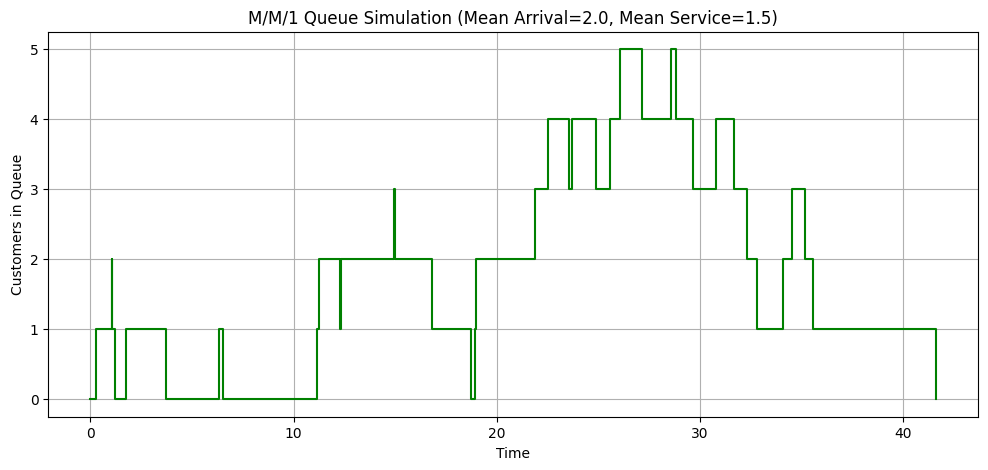

In [169]:
import random
import matplotlib.pyplot as plt

def simulate_mm1(mean_interarrival, mean_service, max_customers):
    # parameter initialization:
    arrival_time = 0
    service_start_time = 0
    total_delay = 0
    server_busy_time = 0
    
    times = [0]
    queue_lengths = [0]
    current_queue = 0
    
    arrival_times = []
    departure_times = []

    for i in range(max_customers):
        # ১. Exponentially Distributed Inter-arrival and  Service time:
        interarrival = random.expovariate(1.0 / mean_interarrival)
        service_time = random.expovariate(1.0 / mean_service)
        
        arrival_time += interarrival
        arrival_times.append(arrival_time)
        
        # 2. (Delay Count):
        # if server free then serving the customer else delay: 1st case(0,0
        service_start_time = max(arrival_time, service_start_time)
        delay = service_start_time - arrival_time
        total_delay += delay
        
        departure_time = service_start_time + service_time
        departure_times.append(departure_time)
        
        server_busy_time += service_time
        service_start_time = departure_time 

    # 3. End of the simulation:
    end_time = departure_times[-1]

    # 4. Now for (Discrete Event) collect graph data:
    all_events = sorted([(t, 1) for t in arrival_times] + [(t, -1) for t in departure_times])
    temp_q = 0
    area_under_q = 0
    last_time = 0
    
    for event_time, change in all_events:
        # Area calculation for Average Number in Queue
        area_under_q += temp_q * (event_time - last_time)
        
        times.append(event_time)
        queue_lengths.append(temp_q)
        temp_q += change
        times.append(event_time)
        queue_lengths.append(temp_q)
        last_time = event_time

    # 5. Result
    print(f"===== Simulation Results =====")
    print(f"Average Delay in Queue: {total_delay / max_customers:.4f}")
    print(f"Time-Average Number of print(all_events)customer in Queue: {area_under_q / end_time:.4f}")
    print(f"Server Utilization: {(server_busy_time / end_time) * 100:.2f}%")
    print(f"Time Simulation Ended: {end_time:.4f}")

    # graph: Q(t) vs T
    plt.figure(figsize=(12, 5))
    plt.step(times, queue_lengths, where='post', color='green', label='Queue Length Q(t)')
    plt.title(f'M/M/1 Queue Simulation (Mean Arrival={mean_interarrival}, Mean Service={mean_service})')
    plt.xlabel('Time')
    plt.ylabel('Customers in Queue')
    plt.grid(True)
    plt.show()

simulate_mm1(mean_interarrival=2.0, mean_service=1.5, max_customers=20)

# Lab02: 
**Inventory management is a crucial aspect of any business that deals with physical goods. Write a program to simulate an inventory system.**


In [ ]:


def simulate_inventory():
    # minimum_stock_level
    s_small = 3   
    # maximum stock level
    S_large = 10  
    initial_inventory = 8
    simulation_days = 25
    
    review_period = 5   
    
    # Demand Table:
    demands = [0, 1, 2, 3, 4]
    demand_probs = [0.10, 0.25, 0.35, 0.21, 0.09]

    # Lead Time Table
    lead_times = [1, 2, 3]
    lead_time_probs = [0.6, 0.3, 0.1]

    # initialization
    current_inventory = initial_inventory
    pending_orders = [] 
    
    print(f"{'Day':<5} | {'Begin Inv':<10} | {'Demand':<8} | {'End Inv':<10} | {'Review?':<10} | {'Order':<10} | {'Lead Time':<10}")
    print("-" * 90)

    for day in range(1, simulation_days + 1):

        # 1️ Check pending orders arrival
        arrived_stock = sum(amt for arr_day, amt in pending_orders if arr_day == day)
        current_inventory += arrived_stock
        
        # remove arrived orders
        pending_orders = [(arr_day, amt) for arr_day, amt in pending_orders if arr_day != day]

        beginning_inv = current_inventory

        # 2 Generate today's demand
        today_demand = random.choices(demands, weights=demand_probs)[0]
        current_inventory -= today_demand
        ending_inv = current_inventory

        review_flag = "No"
        order_placed = "No"
        l_time = "-"

        #  Inventory Review every 5 days
        if day % review_period == 0:
            review_flag = "Yes"

            # total expected inventory (on-hand + on-order)
            total_expected = current_inventory + sum(amt for _, amt in pending_orders)

            if total_expected <= s_small:
                order_amount = S_large - total_expected
                l_time = random.choices(lead_times, weights=lead_time_probs)[0]
                arrival_day = day + l_time
                pending_orders.append((arrival_day, order_amount))
                order_placed = f"Yes({order_amount})"

        print(f"{day:<5} | {beginning_inv:<10} | {today_demand:<8} | {ending_inv:<10} | {review_flag:<10} | {order_placed:<10} | {l_time:<10}")

simulate_inventory()

Day   | Begin Inv  | Demand   | End Inv    | Review?    | Order      | Lead Time 
------------------------------------------------------------------------------------------
1     | 8          | 4        | 4          | No         | No         | -         
2     | 4          | 1        | 3          | No         | No         | -         
3     | 3          | 2        | 1          | No         | No         | -         
4     | 1          | 1        | 0          | No         | No         | -         
5     | 0          | 2        | -2         | Yes        | Yes(12)    | 2         
6     | -2         | 3        | -5         | No         | No         | -         
7     | 7          | 2        | 5          | No         | No         | -         
8     | 5          | 2        | 3          | No         | No         | -         
9     | 3          | 2        | 1          | No         | No         | -         
10    | 1          | 4        | -3         | Yes        | Yes(13)    | 1         
11    |

 
# Lab 03: Write a program to implement Bernouli distribution.


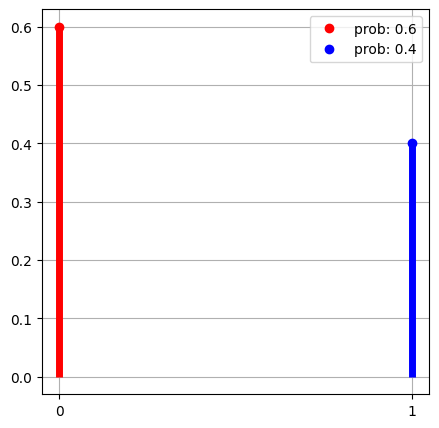

In [2]:


plt.figure(figsize=(5,5))
x = [0,1]
colors = ['red','blue']
y = st.bernoulli.pmf(x,0.4)
plt.vlines(x,ymin=0,ymax=y,colors=colors,lw=5)
plt.plot(x[0],y[0],'o',color=colors[0],label=f"prob: {y[0]}")
plt.plot(x[1],y[1],'o',color=colors[1],label=f"prob: {y[1]}")
plt.xticks([0,1])
plt.grid(True)
plt.legend()
plt.show()



In [3]:

def custom_burnouli_fn(x,p):
    """
    Description: Custom burnoli funtion. Formula, if {1-p, if x=0}, {p if x=1} otherwise zero.
    Args:
        x (array): Two event.
        p (flot): Probability. 
    """
    y = []
    if x[0]==0:
        y.append(1-p)
        y.append(p)
    elif x[0]==1:
        y.append(p)
        y.append(1-p)
    else:
        y.append(0)
        y.append(0)
    return y 
print("0,1 : ",custom_burnouli_fn([0,1],0.2))
print("1,0 : ",custom_burnouli_fn([1,0],0.3))


0,1 :  [0.8, 0.2]
1,0 :  [0.3, 0.7]


# Lab 04: Write a program to implement Binomial distribution.

[29 24 25 33 29 21 29 31 36 31 30 32 34 30 29 32 21 39 28 31 32 34 35 38
 22 26 37 40 26 29 37 29 29 30 34 25 29 31 29 37 25 31 37 26 26 32 23 27
 28 39 36 28 30 40 29 38 31 36 35 30 35 38 29 34 28 32 34 32 34 30 24 33
 38 29 35 28 41 34 26 36 42 25 28 31 30 20 33 34 26 33 27 28 30 29 33 28
 28 28 30 33]


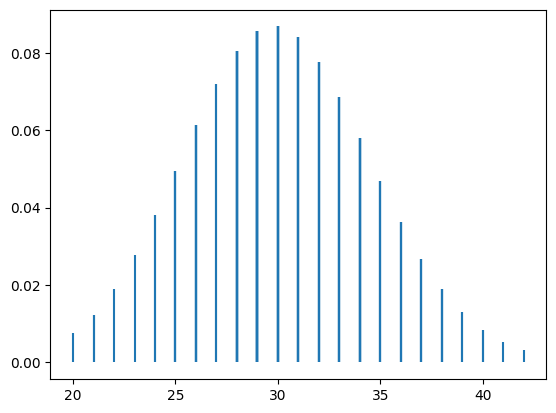

In [4]:


no_of_trials = 100
probability_success = 0.3
x = np.random.binomial(n=no_of_trials,
                       p=probability_success,
                       size=100)
y = st.binom.pmf(x,no_of_trials,probability_success)
print(x)
plt.vlines(x=x,ymin=0,ymax=y)
plt.show()




Binomial PMF:

$P(X=k) = \frac{n!}{k!(n-k)!} \cdot p^k \cdot (1-p)^{n-k}$

* `n` = total trials
* `k` = number of success
* `p` = success probability



[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]


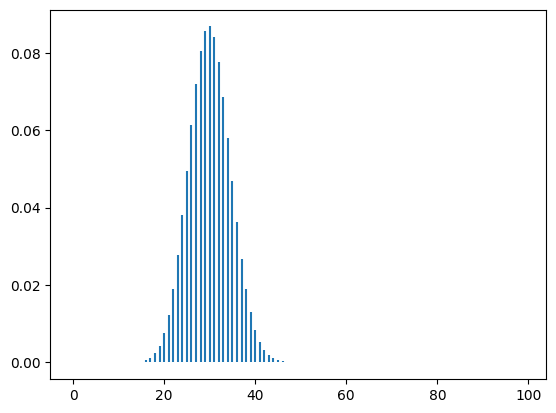

In [9]:

x = [i for i in range(0,100)]

def custom_binomial_pmf(k_array, n, p):
    return np.array([
        math.comb(n, k) * (p**k) * ((1-p)**(n-k))
        for k in k_array
    ])

y = custom_binomial_pmf(x, no_of_trials, probability_success)

print(x)

plt.vlines(x=x, ymin=0, ymax=y)
plt.show()

In [17]:


# ==== The relation of Bernolli and Binomial Distribution ====
# bernolli = binoial([0,1],no_of_trials=1)
print("Binomial: ",custom_binomial_pmf(k_array=[0,1],n=1,p=0.3))
print("Bernoulli: ",st.bernoulli.pmf([0,1],0.3))



Binomial:  [0.7 0.3]
Bernoulli:  [0.7 0.3]


<br>

# Lab 05: Poisson Distribution: 

**A customer care center receives 5 calls per hour. Compute the probability of attending zero calls, one call, two call, ….., ten calls per hour. Simulate the probability mass function respect to the number of receiving call. Show the probability mass function graphs considering 10 and 15 calls per hour.**

<br>

Poisson Distribution:

$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$




mean=5, P(X=0) = 0.00674
mean=5, P(X=1) = 0.03369
mean=5, P(X=2) = 0.08422
mean=5, P(X=3) = 0.14037
mean=5, P(X=4) = 0.17547
mean=5, P(X=5) = 0.17547
mean=5, P(X=6) = 0.14622
mean=5, P(X=7) = 0.10444
mean=5, P(X=8) = 0.06528
mean=5, P(X=9) = 0.03627
mean=5, P(X=10) = 0.01813


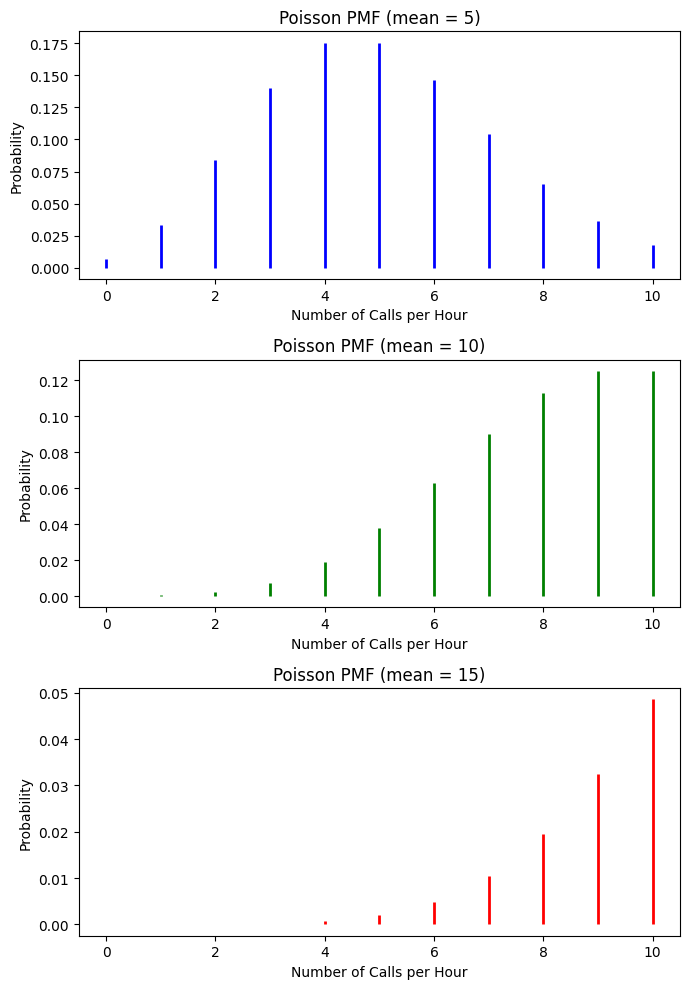

In [159]:

# we need to compute probability of [0 calls, 1 calls, 2 calls .. 10 calls]
k = np.arange(0, 11)

# Figure with 3 rows
fig, ax = plt.subplots(3, 1, figsize=(7, 10))

# ===== mean= 5 =====
y1 = st.poisson.pmf(k, 5)
ax[0].vlines(x=k, ymin=0, ymax=y1, color='b', lw=2)
ax[0].set_xlabel("Number of Calls per Hour")
ax[0].set_ylabel("Probability")
ax[0].set_title("Poisson PMF (mean = 5)")

for i in range(len(k)):
    print(f"mean=5, P(X={k[i]}) = {y1[i]:.5f}")

# ===== mean= 10 =====
y2 = st.poisson.pmf(k, 10)
ax[1].vlines(x=k, ymin=0, ymax=y2, color='g', lw=2)
ax[1].set_xlabel("Number of Calls per Hour")
ax[1].set_ylabel("Probability")
ax[1].set_title("Poisson PMF (mean = 10)")

# ===== mean= 15 =====
y3 = st.poisson.pmf(k, 15)
ax[2].vlines(x=k, ymin=0, ymax=y3, color='r', lw=2)
ax[2].set_xlabel("Number of Calls per Hour")
ax[2].set_ylabel("Probability")
ax[2].set_title("Poisson PMF (mean = 15)")


plt.tight_layout()
plt.show()


# Lab 06: Normal Distribution:
**To Show unimodal and multimodal density curves of normal distribution. To generate random sample with sample size 200, which follows a normal distribution with mean 100 and standard deviation 20. The distribution of diastolic blood pressure for men is normally distributed with a mean of about 80 and a standard deviation of 20. A histogram of the distribution of blood pressures for all mean displays a normal distribution with bell shape.**

Probability Density Function (PDF):
$f(x \mid \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} , \exp\Bigg(-\frac{(x-\mu)^2}{2\sigma^2}\Bigg)$

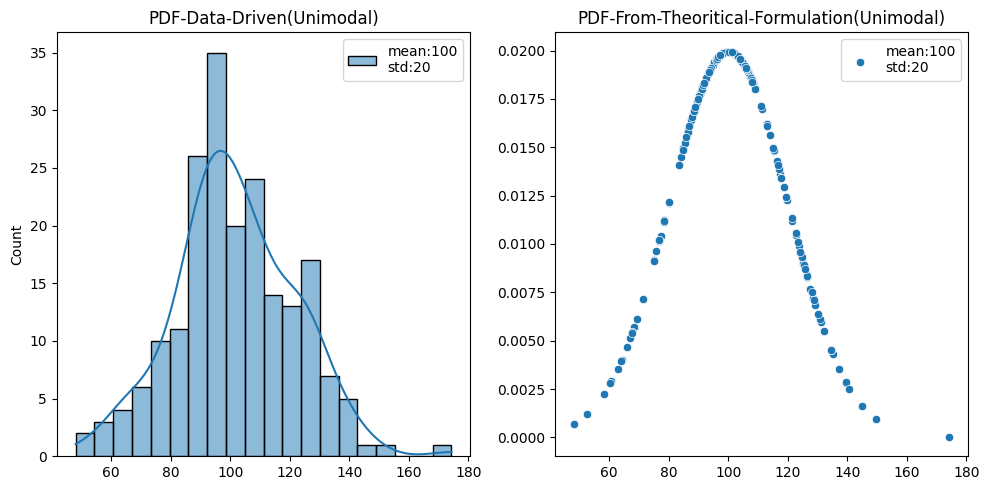

In [131]:


# ===== 1st: Random sample normal distribution ======
sample_size = 200
mean = 100 
std = 20 

x = np.random.normal(loc=mean,scale=std,size=sample_size)
y = st.norm.pdf(x,loc=mean,scale=std)

fig,ax = plt.subplots(1,2,figsize=(10,5))
# if sample_size increase then,we will get more smoother curve
sns.histplot(x=x,bins=20,kde=True,ax=ax[0],label=f"mean:{mean}\nstd:{std}")
ax[0].set_title("PDF-Data-Driven(Unimodal)")
ax[0].legend()

sns.scatterplot(x=x,y=y,ax=ax[1],label=f"mean:{mean}\nstd:{std}")
ax[1].set_title("PDF-From-Theoritical-Formulation(Unimodal)")
ax[1].legend()

plt.tight_layout()
plt.show()



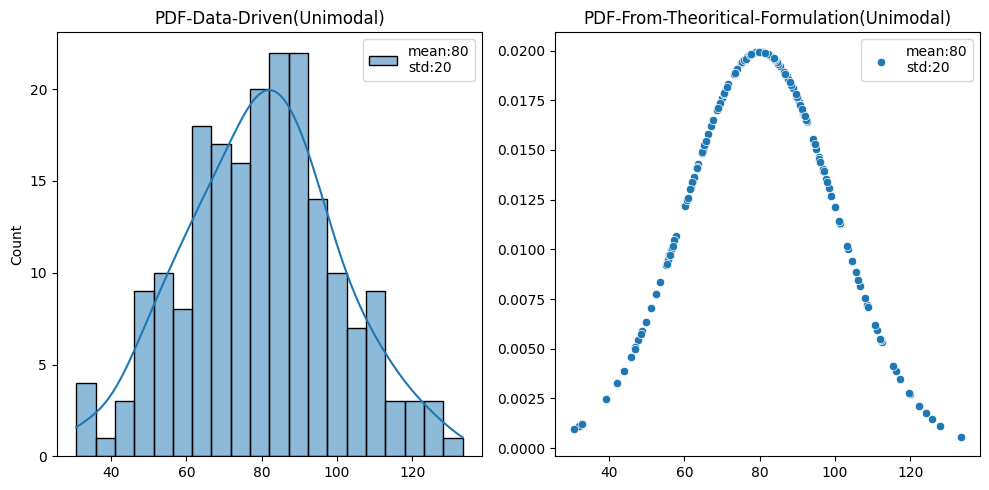

In [128]:


# ======= 2nd: histrogram diastolic blood pressure: ========
sample_size = 200
mean = 80 
std = 20 

x = np.random.normal(loc=mean,scale=std,size=sample_size)
y = st.norm.pdf(x,loc=mean,scale=std)

fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(x=x,bins=20,kde=True,ax=ax[0],label=f"mean:{mean}\nstd:{std}")
ax[0].set_title("PDF-Data-Driven(Unimodal)")
ax[0].legend()

sns.scatterplot(x=x,y=y,ax=ax[1],label=f"mean:{mean}\nstd:{std}")
ax[1].set_title("PDF-From-Theoritical-Formulation(Unimodal)")
ax[1].legend()

plt.tight_layout()
plt.show()




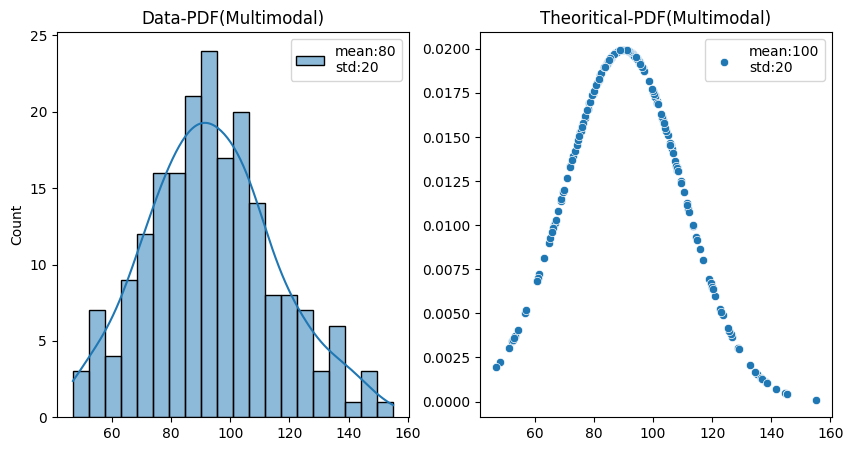

In [144]:

# ======= Multimodal Density Curve ======
mean1 = 80 
mean2 = 100
std1 = 20
std2 = 20 
avg_mean = int((80+100)/2)
avg_std = int((std1+std2)/2)

x1 = np.random.normal(loc=mean1,scale=std1,size=100)   
x2 = np.random.normal(loc=mean2,scale=std2,size=100) 

x_multi = np.concatenate([x1,x2])
y = st.norm.pdf(x=x_multi,loc=avg_mean,scale=avg_std)

fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(x=x_multi,bins=20,kde=True,ax=ax[0],label=f"mean:{mean1}\nstd:{std1}")
ax[0].set_title("Data-PDF(Multimodal)")
ax[0].legend()

sns.scatterplot(x=x_multi,y=y,ax=ax[1],label=f"mean:{mean2}\nstd:{std2}")
ax[1].set_title("Theoritical-PDF(Multimodal)")
ax[1].legend()

plt.show()



# Lab 07: Exponential Distribution:

**There were few waves in COVID-19 pandemic. Let a wave occurs every 100 days in Bangladesh, on average. After a wave occurs, find the probability using Exponential distribution that it will take more than 120 days for the next wave to occur. Simulate several Exponential distribution using rate parameters 0.5, 1.0, 2.0, and 4.0.**

Exponential Distribution (PDF):

$f(x;\lambda) =
\begin{cases}
\lambda e^{-\lambda x}, & x \ge
0, & x < 0
\end{cases}$




In [ ]:

# a wave occurs every 100 days (on average)
mean = 100 
x = 120 

# rate_parameter=lamda
lamda = 1/mean 
print("rate: ",lamda)

next_wave =  np.exp(-(lamda*120))

# there is 30% of probability that next wave will come in next: 120 days 
print(f"P(X=120): {next_wave*100:.2f}")


rate:  0.01
P(X=120): 30.12


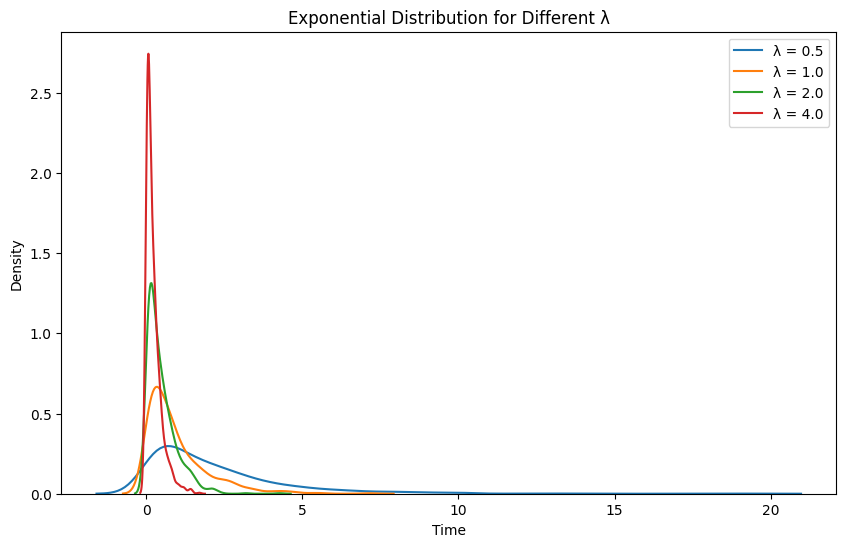

In [153]:

sample_size = 1000
rate_parameters = [0.5, 1.0, 2.0, 4.0]

plt.figure(figsize=(10,6))

for lam in rate_parameters:
    data = np.random.exponential(scale=1/lam, size=sample_size)
    sns.kdeplot(data, label=f"λ = {lam}")

plt.title("Exponential Distribution for Different λ")
plt.xlabel("Time")
plt.ylabel("Density")
plt.legend()
""" 
Observation:
lamda high-> event occur frequently that's why watting time low.
"""
plt.show()
